# TsModels — 时间序列模型估计工具包

本 Notebook 演示 `TsModels` 包的完整用法，包括：

1. **SARIMA 估计** — 建模、诊断、预测
2. **GARCH 估计** — 波动率建模（含纯 ARCH / GARCH / GARCH-M）
3. **IGARCH 持久性检验** — 波动率持续性检验
4. **GARCH-M (ARCH-in-Mean)** — 条件波动率进入均值方程
5. **多模型对比** — `compare_models()` Markdown 表格输出
6. **预测功能** — SARIMA 预测 vs GARCH 波动率预测
7. **与 TsPlots / TsTests 的无缝衔接**
8. **GJR-GARCH** — 非对称 GARCH，杠杆效应
9. **EGARCH** — 指数 GARCH，对数方差建模
10. **STL 分解** — 趋势、季节项、残差与异常值稳健权重

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from Ts.TsSims import simulate_sarima, simulate_garch
from Ts.TsModels import SARIMA, GARCH, STL

---
## 1. SARIMA 模型估计

### 1.1 AR(1) 估计

In [2]:
# 生成 AR(1) 数据: phi = 0.7
sim = simulate_sarima(n=200, order=(1, 0, 0), ar=0.7, seed=42, burn=100)
data = sim.data

# 估计 AR(1)
model = SARIMA(data, order=(1, 0, 0))
result = model.fit()
print(result.summary())
print(f"\n真实 phi = 0.7, 估计 phi_hat = {result.params.get('ar.L1', 'N/A')}")


SARIMA Model Estimation Result
Order: SARIMA(1, 0, 0)
Observations       : 200
Log-Likelihood     : -284.2187
AIC                : 574.4374
BIC                : 584.3324

Parameter Estimates:
--------------------------------------------------
  intercept               -0.0535  (0.0723)  p=0.4593
  ar.L1                    0.6694  (0.0506)  p=0.0000
  sigma2                   1.0013  (0.1007)  p=0.0000

真实 phi = 0.7, 估计 phi_hat = 0.669379795760015


### 1.2 拟合图

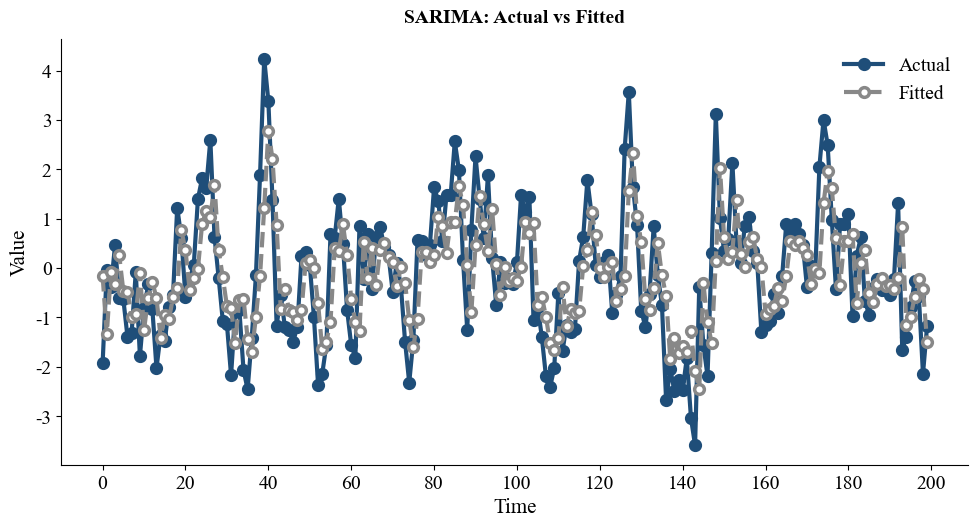

In [3]:
result.plot_fit()
plt.show()


### 1.3 诊断图 — 残差检验 (含白噪音 + 正态性)

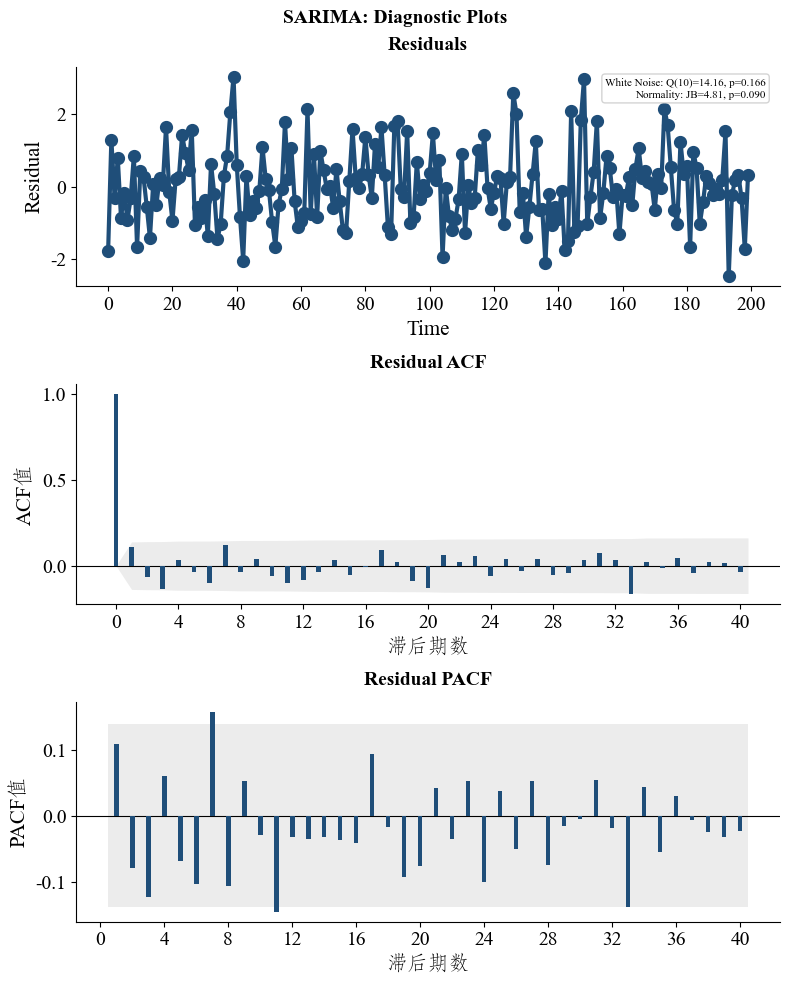

注意: 残差面板右上角标注了白噪音和正态性检验结果


In [4]:
result.plot_diagnostics()
plt.show()
print("注意: 残差面板右上角标注了白噪音和正态性检验结果")


### 1.4 残差统计检验 — 四项检验 (白噪音 + 正态性 + ARCH-Q + ARCH-LM)

In [5]:
tests = result.test_residuals(lags=10)
print(tests)

# 单独访问各项检验结果
print("\n白噪音 (raw Ljung-Box):")
print(f"  Q = {tests.white_noise.statistic:.3f}, p = {tests.white_noise.pvalue:.4f}")
print("\n正态性 (Jarque-Bera):")
print(f"  JB = {tests.normality.statistic:.3f}, p = {tests.normality.pvalue:.4f}")
print(f"  Skewness = {tests.normality.skewness:.4f}, Kurtosis = {tests.normality.kurtosis:.4f}")


Residual Diagnostic Tests
Test                          Statistic    p-value  Conclusion
---------------------------------------------------------------------------
White Noise (Ljung-Box)          14.163     0.1657  White noise
Normality (Jarque-Bera)           4.815     0.0901  Normal
ARCH Effect (Ljung-Box)          11.235     0.3395  No ARCH effects
ARCH Effect (Engle LM)           10.784     0.3746  No ARCH effects

---------------------------------------------------------------------------

  Ljung-Box Q-Test
  Test Statistic: 14.163240
  P-value:        0.165675
  Lags:           10
  H0: No autocorrelation
  Effective obs.      : 200
  Conclusion (5%): Cannot reject H0 (no autocorrelation)

  Jarque-Bera Normality Test
  Test Statistic: 4.814675
  P-value:        0.090055
  Lags:           0
  H0: Normal distribution
  Skewness            : 0.3757
  Kurtosis            : 0.1146
  Effective obs.      : 200
  Conclusion (5%): Cannot reject H0 (normally distributed)

  Ljung-Box Q

### 1.5 MA(1) 估计

In [6]:
sim = simulate_sarima(n=200, order=(0, 0, 1), ma=0.5, seed=456, burn=100)
model = SARIMA(sim.data, order=(0, 0, 1))
result = model.fit()
print(result.summary())


SARIMA Model Estimation Result
Order: SARIMA(0, 0, 1)
Observations       : 200
Log-Likelihood     : -288.0493
AIC                : 582.0986
BIC                : 591.9935

Parameter Estimates:
--------------------------------------------------
  intercept                0.0771  (0.1014)  p=0.4471
  ma.L1                    0.4009  (0.0692)  p=0.0000
  sigma2                   1.0426  (0.1181)  p=0.0000


### 1.6 ARIMA(1,1,0) with trend="ct"

In [7]:
sim = simulate_sarima(n=200, order=(1, 1, 0), ar=0.3, const=0.1, seed=7)
model = SARIMA(sim.data, order=(1, 1, 0))
result = model.fit()
print(result.summary())


SARIMA Model Estimation Result
Order: SARIMA(1, 1, 0)
Observations       : 200
Log-Likelihood     : -271.6256
AIC                : 549.2513
BIC                : 559.1312

Parameter Estimates:
--------------------------------------------------
  intercept               -0.0448  (0.0686)  p=0.5136
  ar.L1                    0.2734  (0.0640)  p=0.0000
  sigma2                   0.8973  (0.0922)  p=0.0000


### 1.7 季节性 SARIMA

In [8]:
sim = simulate_sarima(
    n=300, order=(1, 0, 0), ar=0.5,
    seasonal_order=(1, 0, 0, 4), seasonal_ar=0.3,
    seed=42,
)
model = SARIMA(sim.data, order=(1, 0, 0), seasonal_order=(1, 0, 0, 4))
result = model.fit()
print(result.summary())


SARIMA Model Estimation Result
Order: SARIMA(1, 0, 0)
Seasonal Order: (1, 0, 0, 4)
Observations       : 300
Log-Likelihood     : -427.0368
AIC                : 862.0737
BIC                : 876.8888

Parameter Estimates:
--------------------------------------------------
  intercept                0.0004  (0.0579)  p=0.9951
  ar.L1                    0.5140  (0.0489)  p=0.0000
  ar.S.L4                  0.2626  (0.0516)  p=0.0000
  sigma2                   1.0070  (0.0858)  p=0.0000


### 1.8 SARIMA 预测

预测均值: [ 0.02816641  0.07168302  0.17596197 -0.08374058 -0.00116307]...
95% CI 下界: [-1.93860028 -2.13969254 -2.09564706 -2.37099901 -2.38000742]...
95% CI 上界: [1.9949331  2.28305857 2.44757099 2.20351785 2.37768129]...


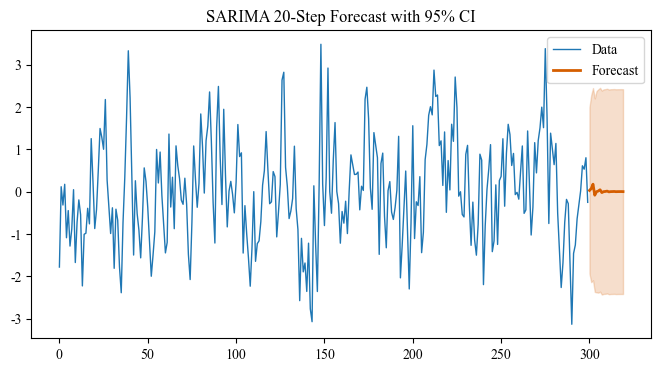

In [9]:
# SARIMA 预测 (样本外 20 步)
pr = result.predict(start=len(sim.data), end=len(sim.data) + 19)
print(f"预测均值: {pr.mean[:5]}...")
print(f"95% CI 下界: {pr.lower[:5]}...")
print(f"95% CI 上界: {pr.upper[:5]}...")

# 可视化
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sim.data, linewidth=1, label="Data")
forecast_idx = range(len(sim.data), len(sim.data) + 20)
ax.plot(forecast_idx, pr.mean, color="#D55E00", linewidth=2, label="Forecast")
ax.fill_between(forecast_idx, pr.lower, pr.upper, alpha=0.2, color="#D55E00")
ax.legend()
ax.set_title("SARIMA 20-Step Forecast with 95% CI")
plt.show()

### 1.9 AR/MA 单位根诊断 — `plot_roots()`

`plot_roots()` 在复平面单位圆上绘制**逆** AR 根和逆 MA 根：

- **蓝色圆点 (●)** = 逆 AR 根 → 全部在单位圆内 = 平稳
- **橙色三角 (▲)** = 逆 MA 根 → 全部在单位圆内 = 可逆

**方法签名：** `plot_roots(title=None) → (fig, ax)`

| 参数 | 类型 | 说明 |
|------|------|------|
| `title` | `str`, optional | 自定义标题。`None` 时自动生成含模型阶数的标题 |
| **返回** | `(Figure, Axes)` | matplotlib 图对象，可进一步修改后保存或显示 |

**相关属性：** `arroots` / `maroots` — 原始 AR/MA 特征根（非逆根）。`1/arroots` 即为图中绘制的逆根。</cell id="7e0332c5">
<｜｜DSML｜｜parameter name="cell_type" string="true">markdown

AR roots: [-1.39696754e+00-0.j          3.24993083e-16-1.39696754j
  3.24993083e-16+1.39696754j  1.39696754e+00-0.j
  1.94547270e+00-0.j        ]
AR inverse roots (plotted): [-7.15836247e-01-0.j          1.66533454e-16+0.71583625j
  1.66533454e-16-0.71583625j  7.15836247e-01+0.j
  5.14013896e-01+0.j        ]


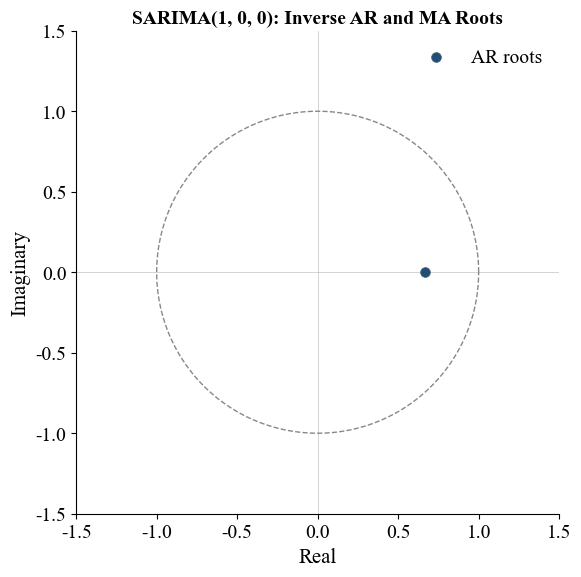

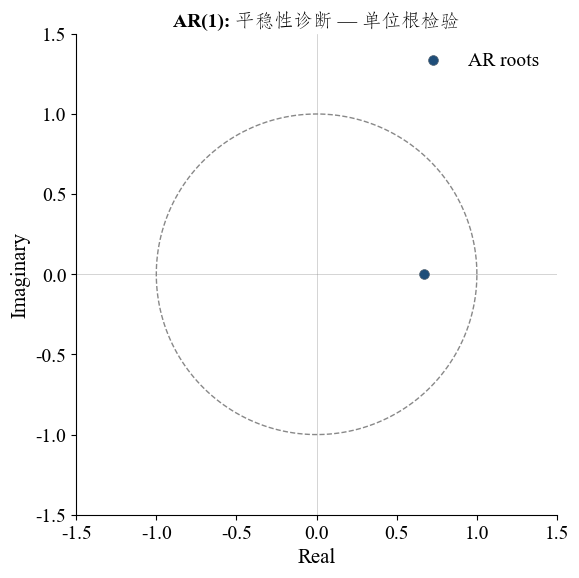

MA roots: [-2.4944468]


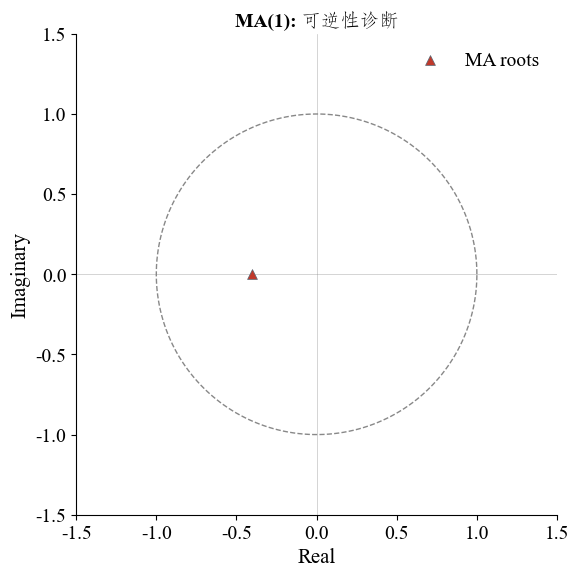

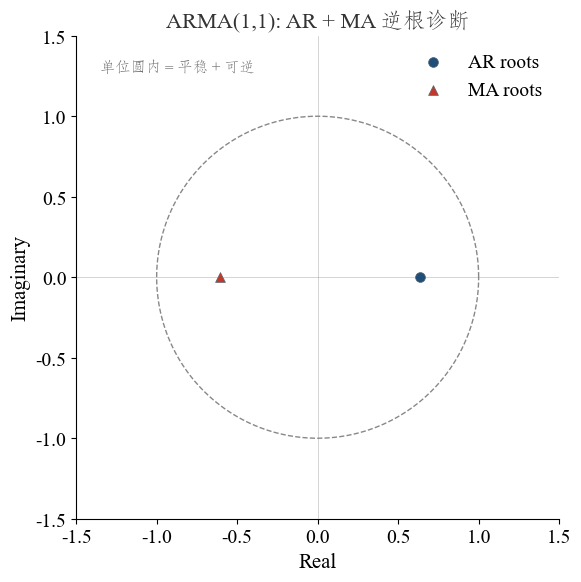

In [10]:
# === 基本用法：默认标题 ===
# 先看原始特征根（非逆根）
print(f"AR roots: {result.arroots}")
print(f"AR inverse roots (plotted): {1.0 / result.arroots}")

# === AR(1) 只有 AR 根 ===
ar1_data = simulate_sarima(n=200, order=(1, 0, 0), ar=0.7, seed=42, burn=100).data
ar1_model = SARIMA(ar1_data, order=(1, 0, 0))
ar1_result = ar1_model.fit()
fig, ax = ar1_result.plot_roots()  # 默认标题: "SARIMA(1, 0, 0): Inverse AR and MA Roots"
plt.show()

# === 自定义标题 ===
fig, ax = ar1_result.plot_roots(title="AR(1): 平稳性诊断 — 单位根检验")
plt.show()

# === MA(1) 只有 MA 根 ===
ma1_data = simulate_sarima(n=200, order=(0, 0, 1), ma=0.5, seed=456, burn=100).data
ma1_model = SARIMA(ma1_data, order=(0, 0, 1))
ma1_result = ma1_model.fit()
print(f"MA roots: {ma1_result.maroots}")
fig, ax = ma1_result.plot_roots(title="MA(1): 可逆性诊断")
plt.show()

# === ARMA(1,1): 同时显示 AR 和 MA 逆根 ===
arma_data = simulate_sarima(n=200, order=(1, 0, 1), ar=[0.7], ma=[0.5], seed=42, burn=100).data
arma_model = SARIMA(arma_data, order=(1, 0, 1))
arma_result = arma_model.fit()
fig, ax = arma_result.plot_roots()

# 利用返回值进一步自定义图形
ax.set_title("ARMA(1,1): AR + MA 逆根诊断", fontsize=16, color="#333333")
ax.annotate("单位圆内 = 平稳 + 可逆", xy=(0.05, 0.95), xycoords="axes fraction",
            fontsize=11, color="#666666", va="top")
plt.show()
# AR 根 (蓝色圆点) 和 MA 根 (橙色三角) 均落在单位圆内 → 平稳且可逆</cell id="9649043e">


---
## 2. 纯 ARCH 估计 (GARCH with q=0)

### 2.1 ARCH(1) 估计 — GARCH(p=1, q=0)

In [11]:
# 生成 ARCH(1): omega = 0.4, alpha1 = 0.5
sim = simulate_garch(n=400, p=1, q=0, omega=0.4, alpha=0.5, seed=789, burn=300)

model = GARCH(sim.data, p=1, q=0)
result = model.fit()
print(result.summary())
print("\n真实 omega=0.4, alpha1=0.5")


ARCH(1) [Normal] Model Estimation Result
Observations       : 400
Log-Likelihood     : -522.6783
AIC                : 1051.3565
BIC                : 1063.3309

Parameter Estimates:
--------------------------------------------------
  mu                      -0.0540  (0.0396)  p=0.1733
  omega                    0.4408  (0.0496)  p=0.0000
  alpha[1]                 0.6010  (0.1207)  p=0.0000

IGARCH Persistence Test (H0: sum(alpha) + sum(beta) = 1):
--------------------------------------------------
  sum(alpha) + sum(beta)   = 0.6010
  Wald chi2(1)          = 10.9278
  p-value               = 0.0009

真实 omega=0.4, alpha1=0.5


### 2.2 条件波动率可视化

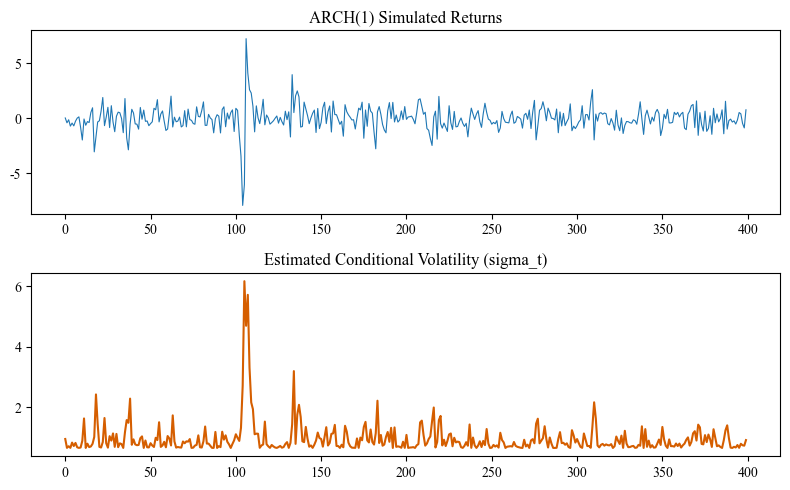

In [12]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5))
ax1.plot(sim.data, linewidth=0.8)
ax1.set_title("ARCH(1) Simulated Returns")
ax2.plot(result.conditional_volatility, color="#D55E00", linewidth=1.5)
ax2.set_title("Estimated Conditional Volatility (sigma_t)")
plt.tight_layout()
plt.show()

### 2.3 ARCH with AR mean — GARCH(p=1, q=0, mean="AR")

In [13]:
sim = simulate_garch(
    n=400, p=1, q=0, omega=0.4, alpha=0.5,
    mean_model="ar", mean_ar=0.6, mean_const=0.5,
    seed=42, burn=200,
)
model = GARCH(sim.data, p=1, q=0, mean="AR")
result = model.fit()
print(result.summary())


ARCH(1) [Normal] Model Estimation Result
Observations       : 400
Log-Likelihood     : -577.1812
AIC                : 1160.3625
BIC                : 1172.3369

Parameter Estimates:
--------------------------------------------------
  Const                    1.2080  (0.0675)  p=0.0000
  omega                    0.4380  (0.0457)  p=0.0000
  alpha[1]                 0.8688  (0.1864)  p=0.0000

IGARCH Persistence Test (H0: sum(alpha) + sum(beta) = 1):
--------------------------------------------------
  sum(alpha) + sum(beta)   = 0.8688
  Wald chi2(1)          = 0.4953
  p-value               = 0.4816


### 2.4 ARCH(2) 估计 — GARCH(p=2, q=0)

In [14]:
sim = simulate_garch(n=400, p=2, q=0, omega=0.2, alpha=[0.3, 0.2], seed=10, burn=200)
model = GARCH(sim.data, p=2, q=0)
result = model.fit()
print(result.summary())


ARCH(2) [Normal] Model Estimation Result
Observations       : 400
Log-Likelihood     : -350.8769
AIC                : 709.7537    Lowest AIC: P = 2
BIC                : 725.7196    Lowest BIC: P = 2

Parameter Estimates:
--------------------------------------------------
  mu                      -0.0019  (0.0281)  p=0.9463
  omega                    0.2268  (0.0287)  p=0.0000
  alpha[1]                 0.2294  (0.1097)  p=0.0365
  alpha[2]                 0.1510  (0.0684)  p=0.0273

IGARCH Persistence Test (H0: sum(alpha) + sum(beta) = 1):
--------------------------------------------------
  sum(alpha) + sum(beta)   = 0.3804
  Wald chi2(1)          = 33.2475
  p-value               = 0.0000


---
## 3. GARCH 模型估计

### 3.1 GARCH(1,1) 估计 + IGARCH 持久性检验

In [15]:
# GARCH(1,1): omega=0.1, alpha=0.2, beta=0.7 (持久性=0.9, 平稳)
sim = simulate_garch(
    n=500, p=1, q=1, omega=0.1, alpha=0.2, beta=0.7,
    seed=123, burn=300,
)
model = GARCH(sim.data, p=1, q=1)
result = model.fit()
print(result.summary())  # summary() 自动包含 IGARCH 持久性检验 + 分布信息


GARCH(1,1) [Normal] Model Estimation Result
Observations       : 500
Log-Likelihood     : -711.4975
AIC                : 1430.9950
BIC                : 1447.8534

Parameter Estimates:
--------------------------------------------------
  mu                      -0.0023  (0.0423)  p=0.9558
  omega                    0.2446  (0.0848)  p=0.0039
  alpha[1]                 0.2274  (0.0598)  p=0.0001
  beta[1]                  0.5513  (0.1094)  p=0.0000

IGARCH Persistence Test (H0: sum(alpha) + sum(beta) = 1):
--------------------------------------------------
  sum(alpha) + sum(beta)   = 0.7787
  Wald chi2(1)          = 7.4018
  p-value               = 0.0065


### 3.2 test_persistence() 详细输出

In [16]:
stab_test = result.test_persistence()
for k, v in stab_test.items():
    print(f"{k:<20s} = {v}")


chi2                 = 7.401768726293456
pvalue               = 0.0065159778650163425
persistence_sum      = 0.7787402248169011
reject_null          = True
conclusion           = Reject H0 (sum = 1) -> model is covariance stationary (sum < 1)


### 3.3 IGARCH 边界检验 — 接近 1 时的行为

In [17]:
# 构造 alpha+beta 接近 1 的 GARCH
sim_igarch = simulate_garch(
    n=500, p=1, q=1, omega=0.05, alpha=0.15, beta=0.83,
    seed=456, burn=300,
)
model2 = GARCH(sim_igarch.data, p=1, q=1)
result2 = model2.fit()
print(result2.summary())
# 注意 IGARCH 检验结论 — alpha+beta=0.98 时可能无法拒绝 H0


GARCH(1,1) [Normal] Model Estimation Result
Observations       : 500
Log-Likelihood     : -851.0227
AIC                : 1710.0453
BIC                : 1726.9038

Parameter Estimates:
--------------------------------------------------
  mu                       0.0049  (0.0523)  p=0.9261
  omega                    0.1253  (0.0682)  p=0.0662
  alpha[1]                 0.2042  (0.0633)  p=0.0013
  beta[1]                  0.7435  (0.0788)  p=0.0000

IGARCH Persistence Test (H0: sum(alpha) + sum(beta) = 1):
--------------------------------------------------
  sum(alpha) + sum(beta)   = 0.9476
  Wald chi2(1)          = 1.5740
  p-value               = 0.2096


### 3.4 Student's t 分布 GARCH — 厚尾新息

`GARCH(data, dist="t")` 即可使用 Student's t 分布。
`summary()` 标题行自动标注分布类型 `[Student's t]`。

In [18]:
sim_t = simulate_garch(
    n=500, p=1, q=1, omega=0.1, alpha=0.2, beta=0.7,
    dist="t", dist_params={"df": 5},
    seed=42, burn=300,
)
model_t = GARCH(sim_t.data, p=1, q=1, dist="t")
result_t = model_t.fit()
print(result_t.summary())
# 注意 nu 参数 — 估计的 t 分布自由度


GARCH(1,1) [Student's t] Model Estimation Result
Observations       : 500
Log-Likelihood     : -621.9733
AIC                : 1253.9465
BIC                : 1275.0196

Parameter Estimates:
--------------------------------------------------
  mu                      -0.0228  (0.0298)  p=0.4427
  omega                    0.1137  (0.0328)  p=0.0005
  alpha[1]                 0.2657  (0.0680)  p=0.0001
  beta[1]                  0.6722  (0.0483)  p=0.0000
  nu                       3.5982  (0.6188)  p=0.0000

IGARCH Persistence Test (H0: sum(alpha) + sum(beta) = 1):
--------------------------------------------------
  sum(alpha) + sum(beta)   = 0.9379
  Wald chi2(1)          = 1.0242
  p-value               = 0.3115


### 3.5 GARCH 分布类型对比

`dist` 参数支持: `"normal"`, `"t"`, `"skewt"`, `"ged"`。

In [19]:
distributions = ["normal", "t", "ged"]
for dist in distributions:
    model = GARCH(sim.data, p=1, q=1, dist=dist)
    r = model.fit()
    print(f"dist={dist:<8s}  AIC={r.aic:.2f}  BIC={r.bic:.2f}")


dist=normal    AIC=1431.00  BIC=1447.85


dist=t         AIC=1433.11  BIC=1454.19


dist=ged       AIC=1432.63  BIC=1453.70


### 3.6 IGARCH 约束估计 — `igarch=True`

IGARCH (Integrated GARCH) 强制约束 sum(alpha) + sum(beta) = 1。
在此约束下，波动率冲击具有永久性，预测方差随 horizon 线性增长。

In [20]:
# IGARCH(1,1) 约束估计 — alpha+beta=1 硬约束
from Ts.TsSims import simulate_igarch

# 生成 IGARCH(1,1) 数据: alpha=0.30, beta=0.70 (自动满足约束)
sim_ig = simulate_igarch(n=500, p=1, q=1, omega=0.05, alpha=[0.30], seed=42)
print(f"simulate_igarch 约束验证: sum(alpha)+sum(beta) = {sum(sim_ig.params['alpha']) + sum(sim_ig.params['beta']):.10f}")

# 用 igarch=True 估计 IGARCH 模型
model_ig = GARCH(sim_ig.data, p=1, q=1, igarch=True)
result_ig = model_ig.fit()
print(result_ig.summary())

# 验证估计结果也满足约束
alpha_hat = sum(v for k, v in result_ig.params.items() if k.startswith("alpha"))
beta_hat = sum(v for k, v in result_ig.params.items() if k.startswith("beta"))
print(f"\n[验证] 估计约束: alpha+beta = {alpha_hat + beta_hat:.10f}")

simulate_igarch 约束验证: sum(alpha)+sum(beta) = 1.0000000000


IGARCH(1,1) [Normal] Model Estimation Result
Observations       : 500
Log-Likelihood     : -744.2786
AIC                : 1492.5572
BIC                : 1500.9864

Parameter Estimates:
--------------------------------------------------
  omega                    0.1127  (0.0303)  p=0.0002
  alpha[1]                 0.4380  (0.0557)  p=0.0000
  beta[1]                  0.5620  (0.0557)  p=0.0000

[验证] 估计约束: alpha+beta = 1.0000000000


C:\Users\NIU\Desktop\Ts\TsSims\_garch_core.py:197: RuntimeWarning: GARCH process is non-stationary / IGARCH: sum(alpha) + sum(beta) = 0.3 + 0.7 = 1.0 >= 1. Using omega = 0.05 as initial variance.
  warnings.warn(


### 3.6.1 IGARCH 预测：方差线性增长

与标准 GARCH 不同，IGARCH 的波动率预测随 horizon 线性增长而不回归均值。

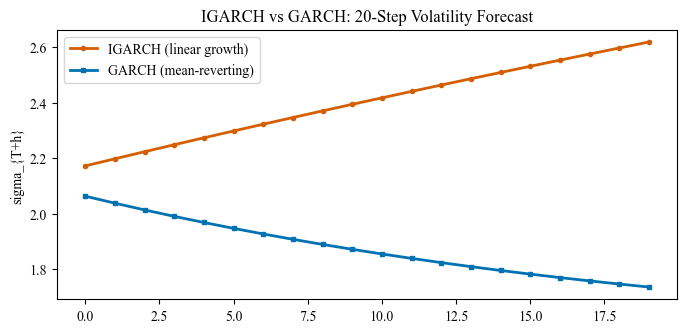

In [21]:
# IGARCH vs GARCH 预测对比
# IGARCH 预测: 方差线性增长，无均值回归
pr_ig = result_ig.predict(start=result_ig.nobs, end=result_ig.nobs + 19)

# 对比: 标准 GARCH 预测 (均值回归)
model_g = GARCH(sim_ig.data, p=1, q=1, igarch=False)
result_g = model_g.fit()
pr_g = result_g.predict(start=result_g.nobs, end=result_g.nobs + 19)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(pr_ig.mean, color="#D55E00", linewidth=2, marker="o", markersize=3, label="IGARCH (linear growth)")
ax.plot(pr_g.mean, color="#0072B2", linewidth=2, marker="s", markersize=3, label="GARCH (mean-reverting)")
ax.set_title("IGARCH vs GARCH: 20-Step Volatility Forecast")
ax.set_ylabel("sigma_{T+h}")
ax.legend()
plt.show()
# IGARCH: 方差随 h 线性增长 (omega * h + sigma2_T)
# GARCH: 方差回归到无条件均值

---
## 4. 波动率预测

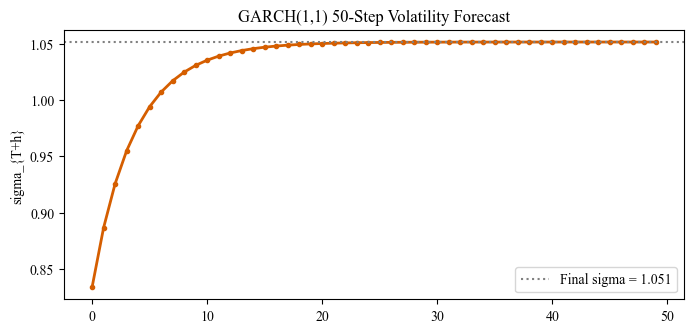

In [22]:
# ARCH 波动率预测
pr = result.predict(start=result.nobs, end=result.nobs + 49)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(pr.mean, color="#D55E00", linewidth=2, marker="o", markersize=3)
ax.axhline(pr.mean[-1], color="gray", linestyle=":", label=f"Final sigma = {pr.mean[-1]:.3f}")
ax.set_title("GARCH(1,1) 50-Step Volatility Forecast")
ax.set_ylabel("sigma_{T+h}")
ax.legend()
plt.show()

---
## 5. 工作流集成

TsSims -> TsModels -> TsPlots / TsTests 的完整链条。
诊断图自动显示白噪音和正态性检验结果。

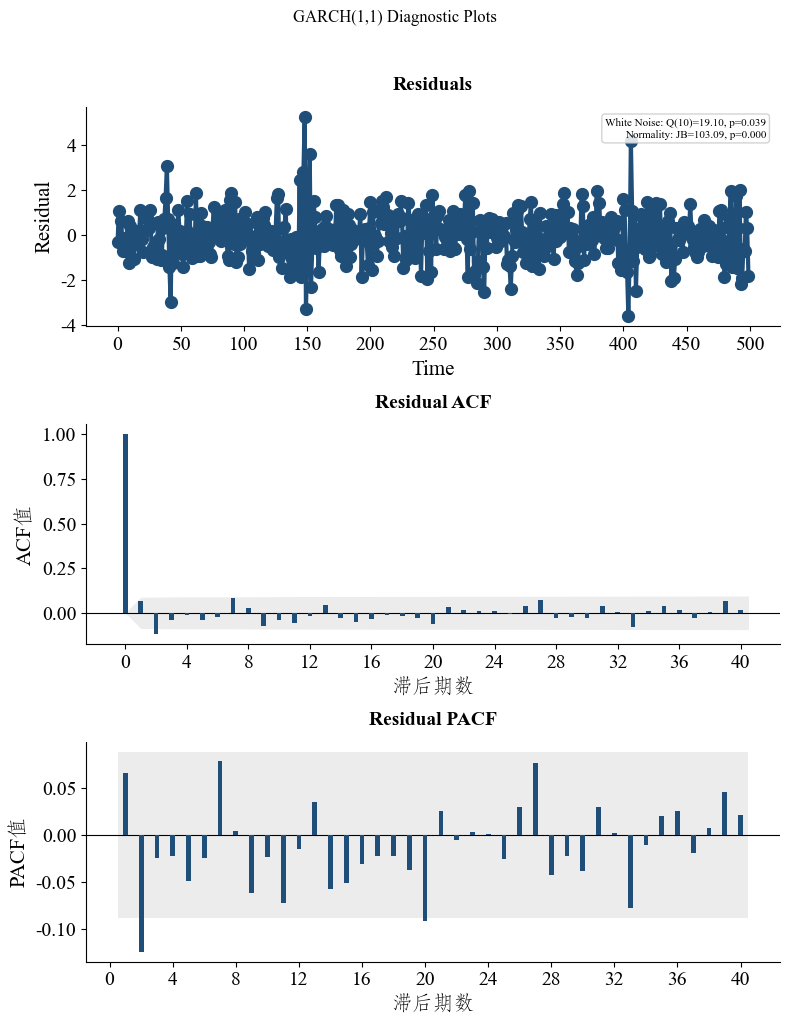

Residual Diagnostic Tests
Test                          Statistic    p-value  Conclusion
---------------------------------------------------------------------------
White Noise (Ljung-Box)          19.096     0.0391  Autocorrelation
Normality (Jarque-Bera)         103.086     0.0000  Non-normal
ARCH Effect (Ljung-Box)         149.877     0.0000  ARCH effects
ARCH Effect (Engle LM)           88.374     0.0000  ARCH effects

---------------------------------------------------------------------------

  Ljung-Box Q-Test
  Test Statistic: 19.096288
  P-value:        0.039057
  Lags:           10
  H0: No autocorrelation
  Effective obs.      : 500
  Conclusion (5%): Reject H0 (autocorrelation present)

  Jarque-Bera Normality Test
  Test Statistic: 103.086200
  P-value:        0.000000
  Lags:           0
  H0: Normal distribution
  Skewness            : 0.2999
  Kurtosis            : 2.1421
  Effective obs.      : 500
  Conclusion (5%): Reject H0 (not normally distributed)

  Ljung-Box Q-

In [23]:
# Step 1: 模拟数据
sim = simulate_garch(n=500, p=1, q=1, omega=0.1, alpha=0.2, beta=0.7, seed=42)

# Step 2: 估计模型
model = GARCH(sim.data, p=1, q=1)
result = model.fit()

# Step 3a: 绘图诊断 (残差面板自动显示白噪音 + 正态性检验)
result.plot_diagnostics()
plt.suptitle("GARCH(1,1) Diagnostic Plots", y=1.02)
plt.show()

# Step 3b: 四项统计检验
tests = result.test_residuals(lags=10)
print(tests)

# Step 3c: IGARCH 持久性检验
stab = result.test_persistence()
print("\n波动率持久性:")
print(f"  persistence_sum = {stab['persistence_sum']:.4f}")
print(f"  chi2(1) = {stab['chi2']:.3f}, p = {stab['pvalue']:.4f}")
print(f"  结论: {stab['conclusion']}")

| `SARIMAResult` | `summary()`, `plot_fit()`, `plot_diagnostics()`, `test_residuals()` | `predict()`, `arroots`, `maroots`, `plot_roots()` |
| `GARCHResult` | 同上 + `dist`, `garch_m`, `garch_m_form` | `predict()`, `test_persistence()`, `conditional_volatility` |
| `VARResult` | 同上（2-D fitted_values/residuals） | `irf()` → `IRFResult`, `oirf()`, `fevd()` → `FEVDResult`, `plot_irf()`, `granger_causality()`, `predict()`, `is_stable`, `plot_roots()` |
| `SVARResult` | 同上（继承 VARResult）+ `A`, `B`, `sigma_u` | `sirf()` → 结构性 IRF, `structural_residuals` |
| `VECMResult` | `summary()`（Stata风格）, `plot_diagnostics()`, `test_residuals()` | `irf()`, `fevd()`, `predict()`, `granger_causality()`, `is_stable`, `plot_roots()`, `alpha`/`beta`/`gamma`/`sigma_u` |

---

## 6. GARCH-M (ARCH-in-Mean) 估计

GARCH-M 将条件波动率引入均值方程：

$$
y_t = \mu + \lambda \cdot \sigma_t + \varepsilon_t
$$

ARCH-in-mean 系数在结果中对应参数 `kappa`。

In [24]:
# GARCH-M(1,1): sigma_t 进入均值方程
sim = simulate_garch(
    n=500, p=1, q=1, omega=0.1, alpha=0.2, beta=0.7,
    seed=42, burn=300,
)
model_m = GARCH(sim.data, p=1, q=1, garch_m=True)
result_m = model_m.fit()
print(result_m.summary())
# 注意 kappa 参数 — 均值方程中条件波动率的系数

GARCH(1,1) [Normal] [ARCH-in-mean, form=vol] Model Estimation Result
Observations       : 500
Log-Likelihood     : -689.8789
AIC                : 1389.7577
BIC                : 1410.8308

Parameter Estimates:
--------------------------------------------------
  Const                    0.0313  (0.2025)  p=0.8771
  kappa                   -0.0430  (0.2188)  p=0.8442
  omega                    0.1870  (0.0516)  p=0.0003
  alpha[1]                 0.2419  (0.0561)  p=0.0000
  beta[1]                  0.5752  (0.0625)  p=0.0000

IGARCH Persistence Test (H0: sum(alpha) + sum(beta) = 1):
--------------------------------------------------
  sum(alpha) + sum(beta)   = 0.8171
  Wald chi2(1)          = 8.4710
  p-value               = 0.0036


### 6.1 GARCH-M 形式对比

`garch_m_form` 控制 sigma 进入均值方程的形式：

| 值 | 均值方程项 |
|----|-----------|
| `"vol"` | $\lambda \cdot \sigma_t$ |
| `"var"` | $\lambda \cdot \sigma_t^2$ |
| `"log"` | $\lambda \cdot \log(\sigma_t^2)$ |

In [25]:
forms = ["vol", "var", "log"]
for form in forms:
    model = GARCH(sim.data, p=1, q=1, garch_m=True, garch_m_form=form)
    r = model.fit()
    kappa = r.params.get("kappa", np.nan)
    print(f"form={form:<5s}  kappa={kappa:<12.6f}  AIC={r.aic:.2f}  BIC={r.bic:.2f}")

form=vol    kappa=-0.042990     AIC=1389.76  BIC=1410.83
form=var    kappa=-0.026533     AIC=1389.73  BIC=1410.80
form=log    kappa=-0.013616     AIC=1389.78  BIC=1410.85


---

## 7. 多模型结果对比 — `compare_models`

支持将多个模型的 AIC、BIC、Log-Likelihood、参数估计值及显著性星号
整合为 Markdown 表格，便于横向比较。

In [26]:
from Ts.TsModels import compare_models

# 拟合多个模型
model_base = GARCH(sim.data, p=1, q=1)
result_base = model_base.fit()

model_m = GARCH(sim.data, p=1, q=1, garch_m=True)
result_m = model_m.fit()

model_t = GARCH(sim.data, p=1, q=1, dist="t")
result_t = model_t.fit()

# Markdown 对比表格
table = compare_models({
    "GARCH(1,1) [Normal]": result_base,
    "GARCH-M(1,1) [Normal]": result_m,
    "GARCH(1,1) [t]": result_t,
})
print(table)
# 参数估计值含标准误和显著性星号 (*** p<0.01, ** p<0.05, * p<0.1)

-------------------------------------------------------------------
                           (1)            (2)            (3)      
                      GARCH(1,1) [Normal] GARCH-M(1,1) [Normal] GARCH(1,1) [t]
-------------------------------------------------------------------
main
  mu                    -0.0076                       -0.0076    
                        (-0.20)                       (-0.20)    
  Const                                 0.0313                   
                                        (0.15)                   
ARCHM
  kappa                                -0.0430                   
                                       (-0.20)                   
ARCH
  omega                0.1849***      0.1870***      0.1858***   
                         (3.77)         (3.62)         (3.75)    
  alpha[1]             0.2415***      0.2419***      0.2419***   
                         (4.30)         (4.31)         (4.31)    
  beta[1]              0.5778***      0.57

---

## 8. GJR-GARCH（非对称 GARCH）估计

GJR-GARCH (Glosten-Jagannathan-Runkle) 通过 `o` 参数引入杠杆效应。
`o>=1` 时，负向冲击对波动率的影响大于正向冲击（gamma 系数）。

In [27]:
# GJR-GARCH(1,1,1) 估计
np.random.seed(123)
n = 500
omega, alpha, gamma, beta = 0.05, 0.10, 0.15, 0.75
eps = np.random.randn(n)
sigma2 = np.zeros(n)
e = np.zeros(n)
sigma2[0] = omega / (1 - alpha - 0.5 * gamma - beta)
e[0] = np.sqrt(sigma2[0]) * eps[0]
for t in range(1, n):
    I_neg = 1.0 if e[t - 1] < 0 else 0.0
    sigma2[t] = omega + alpha * e[t - 1]**2 \
               + gamma * I_neg * e[t - 1]**2 \
               + beta * sigma2[t - 1]
    e[t] = np.sqrt(max(sigma2[t], 1e-10)) * eps[t]
y = 1.0 + e

model_gjr = GARCH(y, p=1, o=1, q=1)
result_gjr = model_gjr.fit()
print(result_gjr.summary())
# gamma[1] > 0 表示杠杆效应: 负向冲击增加波动率

GJR-GARCH(1,1,1) [Normal] Model Estimation Result
Observations       : 500
Log-Likelihood     : -569.8963
AIC                : 1149.7927
BIC                : 1170.8657

Parameter Estimates:
--------------------------------------------------
  mu                       0.9578  (0.0323)  p=0.0000
  omega                    0.0252  (0.0110)  p=0.0225
  alpha[1]                 0.0331  (0.0241)  p=0.1697
  gamma[1]                 0.1564  (0.0492)  p=0.0015
  beta[1]                  0.8548  (0.0362)  p=0.0000

IGARCH Persistence Test (H0: sum(alpha) + 0.5*sum(gamma) + sum(beta) = 1):
--------------------------------------------------
  sum(alpha)+0.5*sum(gamma)+sum(beta) = 0.9662
  Wald chi2(1)          = 2.6989
  p-value               = 0.1004


---

## 9. EGARCH（指数 GARCH）估计

EGARCH (Nelson 1991) 对对数方差建模，天然保证方差为正。
通过 `vol="EGARCH"` 参数启用，`o>=1` 引入非对称杠杆效应。

In [28]:
# EGARCH(1,1,1) 估计
np.random.seed(123)
n = 500
omega, alpha, gamma, beta = 0.05, 0.20, 0.10, 0.30
eps = np.random.randn(n)
ln_sigma2_sim = np.zeros(n)
e_sim = np.zeros(n)
ln_sigma2_sim[0] = omega
sigma2_0 = np.exp(ln_sigma2_sim[0])
e_sim[0] = np.sqrt(sigma2_0) * eps[0]
for t in range(1, n):
    z = eps[t]
    ln_sigma2_sim[t] = (omega
                       + alpha * (abs(z) - np.sqrt(2.0 / np.pi))
                       + gamma * z
                       + beta * ln_sigma2_sim[t - 1])
    e_sim[t] = np.sqrt(np.exp(ln_sigma2_sim[t])) * z
y_egarch = 1.0 + e_sim

model_egarch = GARCH(y_egarch, p=1, o=1, q=1, vol="EGARCH")
result_egarch = model_egarch.fit()
print(result_egarch.summary())
# EGARCH 持久性仅检验 sum(beta)=1，不含 alpha/gamma

EGARCH(1,1,1) [Normal] Model Estimation Result
Observations       : 500
Log-Likelihood     : -760.3196
AIC                : 1530.6392
BIC                : 1551.7123

Parameter Estimates:
--------------------------------------------------
  mu                       0.9983  (0.0000)  p=0.0000
  omega                   -0.0013  (0.0000)  p=0.0000
  alpha[1]                -0.0413  (0.0002)  p=0.0000
  gamma[1]                -0.0137  (0.0001)  p=0.0000
  beta[1]                  1.0000  (0.0000)  p=0.0000

IGARCH Persistence Test (H0: sum(beta) = 1):
--------------------------------------------------
  sum(beta)                = 1.0000
  Wald chi2(1)          = 0.0000
  p-value               = 1.0000


---

## 10. AutoSARIMA / AutoGARCH — 自动最优参数选择

`AutoSARIMA` 和 `AutoGARCH` 通过网格搜索自动选择使信息准则 (AIC/BIC/HQIC/AICC)
最小的模型阶数。`AutoGARCH` 支持全部 GARCH 族变体：标准 GARCH、GJR-GARCH、
EGARCH、IGARCH、GARCH-M。

### 10.1 AutoSARIMA — 自动选择最优 ARIMA 阶数

In [29]:
from Ts.TsModels import AutoSARIMA, AutoGARCH
from Ts.TsSims import simulate_egarch, simulate_igarch, simulate_garch_m

# AutoSARIMA: 自动搜索 (p,d,q) 最优阶数
sim_ar = simulate_sarima(n=200, order=(1, 0, 0), ar=[0.7], seed=42)
auto_ar = AutoSARIMA(sim_ar.data, p=(0, 3), d=(0, 1), q=(0, 3), criterion="aic")
result_ar = auto_ar.fit()
print(result_ar.summary())
print(f"\n最优阶数: {result_ar.best_order}")

Auto SARIMA Model Selection Result
Search Method      : grid
Selection Criterion: AIC
Best Order         : (3, 0, 2)
Models Evaluated   : 32/32 successful
Search Diagnostics : 47
Best    AIC        : 562.9776

Best Model Details:
------------------------------------------------------------
SARIMA Model Estimation Result
Observations       : 200
Log-Likelihood     : -274.4888
AIC                : 562.9776
BIC                : 586.0659

Parameter Estimates:
--------------------------------------------------
  intercept               -0.1706  (0.2272)  p=0.4527
  ar.L1                   -0.5424  (0.0685)  p=0.0000
  ar.L2                   -0.0399  (0.0775)  p=0.6066
  ar.L3                    0.4696  (0.0748)  p=0.0000
  ma.L1                    1.3436  (0.7660)  p=0.0794
  ma.L2                    0.9994  (1.1402)  p=0.3807
  sigma2                   0.8844  (0.9962)  p=0.3747

最优阶数: (3, 0, 2)


### 10.2 AutoGARCH — EGARCH 自动选择

`vol="EGARCH"` 启用 EGARCH 模型的自动阶数选择。

In [30]:
# AutoGARCH + EGARCH: 自动搜索最优 EGARCH(p,o,q) 阶数
sim_eg = simulate_egarch(n=300, p=1, q=1, o=1, seed=42, burn=200)
auto_eg = AutoGARCH(sim_eg.data, p=(1, 2), q=(1, 2), o=(1, 1),
                    vol="EGARCH", criterion="aic")
result_eg = auto_eg.fit()
print(result_eg.summary())

Auto EGARCH Model Selection Result
Search Method      : grid
Selection Criterion: AIC
Best Order         : (1, 1, 1)
Models Evaluated   : 4/4 successful
Search Diagnostics : 0
Best    AIC        : 862.9619

Best Model Details:
------------------------------------------------------------
EGARCH Model Estimation Result
Observations       : 300
Log-Likelihood     : -426.4810
AIC                : 862.9619
BIC                : 881.4808

Parameter Estimates:
--------------------------------------------------
  mu                      -0.0020  (0.0582)  p=0.9732
  omega                    0.0063  (0.0838)  p=0.9404
  alpha[1]                 0.2910  (0.1475)  p=0.0485
  gamma[1]                 0.1510  (0.0726)  p=0.0374
  beta[1]                  0.0459  (0.3413)  p=0.8931


### 10.3 AutoGARCH — IGARCH 自动选择

`igarch=True` 启用 IGARCH 约束估计的自动阶数选择。

In [31]:
# AutoGARCH + IGARCH: 自动搜索最优 IGARCH(p,q) 阶数
sim_ig = simulate_igarch(n=300, p=1, q=1, omega=0.10, alpha=[0.20], seed=42, burn=200)
auto_ig = AutoGARCH(sim_ig.data, p=(1, 2), q=(1, 2),
                    igarch=True, criterion="bic")
result_ig = auto_ig.fit()
print(result_ig.summary())

C:\Users\NIU\Desktop\Ts\TsSims\_garch_core.py:197: RuntimeWarning: GARCH process is non-stationary / IGARCH: sum(alpha) + sum(beta) = 0.2 + 0.8 = 1.0 >= 1. Using omega = 0.1 as initial variance.
  warnings.warn(


Auto IGARCH Model Selection Result
Search Method      : grid
Selection Criterion: BIC
Best Order         : (1, 0, 1)
Models Evaluated   : 4/4 successful
Search Diagnostics : 0
Best    BIC        : 1299.2531

Best Model Details:
------------------------------------------------------------
IGARCH Model Estimation Result
Observations       : 300
Log-Likelihood     : -643.9228
AIC                : 1291.8455
BIC                : 1299.2531

Parameter Estimates:
--------------------------------------------------
  omega                    0.4333  (0.1759)  p=0.0138
  alpha[1]                 0.3770  (0.0843)  p=0.0000
  beta[1]                  0.6230  (0.0843)  p=0.0000


### 10.4 AutoGARCH — GARCH-M 自动选择

`garch_m=True` 启用 GARCH-M (ARCH-in-mean) 的自动阶数选择。

In [32]:
# AutoGARCH + GARCH-M: 自动搜索最优 GARCH-M(p,q) 阶数
sim_m = simulate_garch_m(n=300, p=1, q=1, omega=0.10, alpha=[0.20], beta=[0.60],
                         garch_m_kappa=0.20, seed=42, burn=200)
auto_m = AutoGARCH(sim_m.data, p=(1, 2), q=(1, 2),
                   garch_m=True, criterion="aic")
result_m = auto_m.fit()
print(result_m.summary())

Auto GARCH Model Selection Result
Search Method      : grid
Selection Criterion: AIC
Best Order         : (1, 0, 1)
Models Evaluated   : 4/4 successful
Search Diagnostics : 0
Best    AIC        : 825.0848

Best Model Details:
------------------------------------------------------------
GARCH Model Estimation Result
Observations       : 300
Log-Likelihood     : -407.5424
AIC                : 825.0848
BIC                : 843.6037

Parameter Estimates:
--------------------------------------------------
  Const                    0.1547  (0.2047)  p=0.4499
  kappa                   -0.0389  (0.3032)  p=0.8978
  omega                    0.1370  (0.0433)  p=0.0016
  alpha[1]                 0.2808  (0.0841)  p=0.0008
  beta[1]                  0.4623  (0.1020)  p=0.0000


---

## 11. VAR — 向量自回归

VAR 是多变量时间序列分析的基础模型。每个变量由其自身滞后值和其他变量的滞后值共同解释。

In [33]:
import numpy as np
from Ts.TsModels import VAR
from Ts.TsSims import simulate_sarima

# 生成两个相关的 AR(1) 过程作为 VAR 数据
r0 = simulate_sarima(n=200, order=(1, 0, 0), ar=[0.7], seed=42, burn=100)
r1 = simulate_sarima(n=200, order=(1, 0, 0), ar=[0.5], seed=99, burn=100)
data_2d = np.column_stack([r0.data, r1.data])

# VAR(2) 估计
model = VAR(data_2d, lags=2, cols=["y0", "y1"])
result = model.fit()
print(result.summary())

VAR(2) Model Estimation Result
Variables  : y0, y1
Observations: 198
Log-Likelihood: -564.6925
AIC         : 0.1292
BIC         : 0.2953

Equation: y0
----------------------------------------
  L1.y0                              0.7941  (0.0705)  p=0.0000
  L1.y1                             -0.0821  (0.0665)  p=0.2170
  L2.y0                             -0.1826  (0.0706)  p=0.0097
  L2.y1                              0.0444  (0.0665)  p=0.5045
  const                             -0.0544  (0.0709)  p=0.4431
  const                             -0.0544  (0.0709)  p=0.4431

Equation: y1
----------------------------------------
  L1.y0                             -0.1630  (0.0750)  p=0.0298
  L1.y1                              0.5401  (0.0707)  p=0.0000
  L2.y0                              0.1769  (0.0751)  p=0.0185
  L2.y1                              0.0408  (0.0707)  p=0.5635
  const                             -0.0316  (0.0754)  p=0.6755
  const                             -0.0316  (0.0

### 11.1 滞后阶数选择

`VAR.select_order()` 静态方法基于信息准则选择最优滞后阶数。

In [34]:
order_info = VAR.select_order(data_2d, max_lags=8, criterion="aic")
print(order_info)

VAR Lag Order Selection Criteria
Endogenous: y0, y1
Sample: 200 observations
Selection criterion: AIC

 lag          LL          LR    df         p         FPE         AIC         BIC        HQIC
--------------------------------------------------------------------------------------------
   0   -675.0774                              3.0331e+00      1.1096      1.1435      1.1233
   1   -574.9977    200.1594     4    0.0000  1.1875e+00      0.1719      0.2737      0.2131
   2   -564.6925     20.6105     4    0.0004  1.1490e+00*     0.1389*     0.3085*     0.2076*
   3   -561.6853      6.0144     4    0.1981  1.1864e+00      0.1709      0.4084      0.2671
   4   -556.0290     11.3126     4    0.0233  1.1903e+00      0.1741      0.4795      0.2978
   5   -546.5543     18.9494     4    0.0008  1.1809e+00      0.1660      0.5393      0.3172
   6   -539.9567     13.1951     4    0.0104  1.1860e+00      0.1702      0.6113      0.3488
   7   -535.9032      8.1071     4    0.0877  1.2202e+00   

### 11.2 脉冲响应函数 (IRF)

IRF 展示一个变量的冲击如何随时间影响其他变量。

Raw IRF values shape: (11, 2, 2)  (periods+1, k, k)
Orth IRF values shape: (11, 2, 2)  (periods+1, k, k)

y0 -> y1 shock: step=[0, 1, 2, 3], value=[ 0.         -0.08205328 -0.06511699 -0.04115581]
  95% CI 下界: [ 0.         -0.21232312 -0.21370586 -0.19866739]
  95% CI 上界: [0.         0.04821656 0.08347188 0.11635576]

IRF Results (95% CI)
Variables: y0, y1
Periods: 10

+--------------------------------------------------+
|      |      (1) |      (2) |      (3) |      (4) |
| step |      irf |      irf |      irf |      irf |
|------+----------+----------+----------+----------|
| 0    |        1 |        0 |        0 |        1 |
| 1    |  .794142 | -.162955 | -.082053 |  .540083 |
| 2    |  .461475 | -.040476 | -.065117 |  .345891 |
| 3    |  .217593 |  .036804 | -.041156 |  .204954 |
| 4    |  .083738 |  .064422 | -.022269 |      .12 |
| 5    |  .023124 |  .061152 | -.010926 |  .069525 |
| 6    |  .000917 |  .046706 | -.004993 |  .040289 |
| 7    | -.004613 |  .031664 | -.002192 |  .0

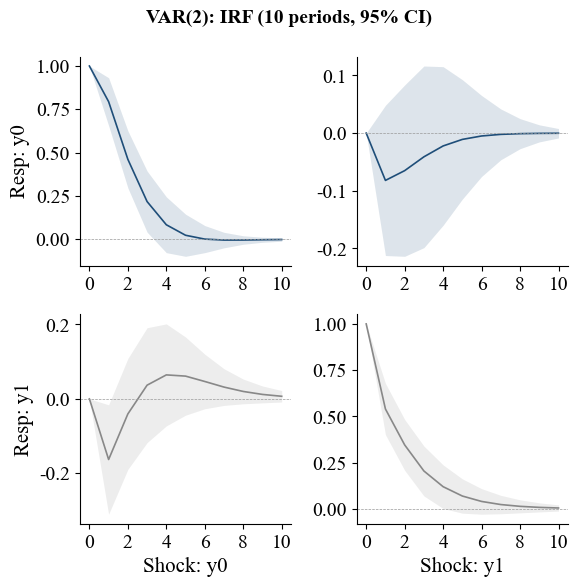

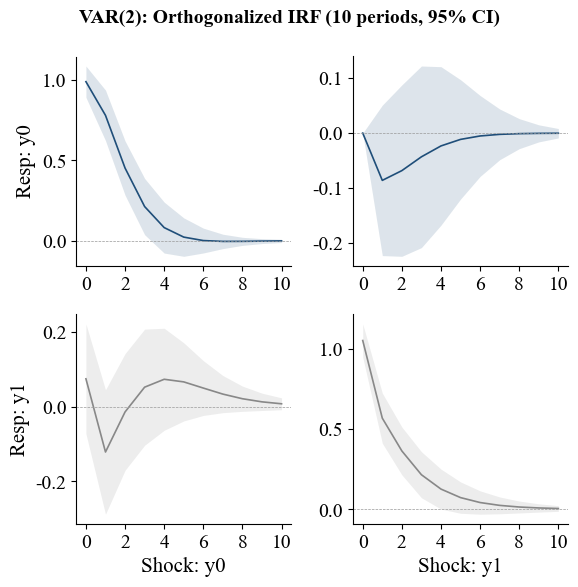

In [35]:
# === 非正交化 IRF — 返回 IRFResult（含 .values / .lower / .upper / .summary() / .get()） ===
irf_result = result.irf(periods=10, orth=False)
print(f"Raw IRF values shape: {irf_result.values.shape}  (periods+1, k, k)")
# irf_result.values[h, i, j] = 变量 i 对冲击 j 在第 h 期的响应

# === 正交化 IRF (Cholesky 分解) — OIRF ===
irf_orth_result = result.irf(periods=10, orth=True)
print(f"Orth IRF values shape: {irf_orth_result.values.shape}  (periods+1, k, k)")

# === 正交化 IRF 的显式调用方式 ===
oirf_result = result.irf(periods=10, orth=True)

# === 提取单个响应路径: y0 对 y1 冲击的响应 ===
d = irf_result.get("y0", "y1")
print(f"\ny0 -> y1 shock: step={d['step'][:4]}, value={d['value'][:4]}")
print(f"  95% CI 下界: {d['lower'][:4]}")
print(f"  95% CI 上界: {d['upper'][:4]}")

# === 查看 Stata 风格表格 ===
print("\n" + irf_result.summary())

# 验证: 正交 IRF 与原始 IRF 不同
print(f"\nOIRF differs from raw: {not np.allclose(irf_result.values, irf_orth_result.values)}")

# 第二次调用 (相同 periods) 自动从缓存读取，不重复计算
irf_result2 = result.irf(periods=10, orth=False)
print(f"Cached result matches: {np.allclose(irf_result.values, irf_result2.values)}")

# 绘制 IRF (含 95% 置信带)
fig, axes = result.plot_irf(periods=10, orth=False)
plt.show()

# 绘制正交化 IRF
fig, axes = result.plot_irf(periods=10, orth=True)
plt.show()

### 11.3 预测误差方差分解 (FEVD) 与 Granger 因果检验

In [36]:
# 方差分解 — 返回 FEVDResult（含 Monte Carlo 置信区间 + .summary() + .get()）
fevd_result = result.fevd(periods=10, n_draws=200, seed=42)
print(f"FEVD values shape: {fevd_result.values.shape}  (periods, k, k)")

# === Stata 风格表格输出 ===
print(fevd_result.summary())

# === 提取单个响应-冲击对的方差分解 ===
d = fevd_result.get("y0", "y1")
print("\ny0 <- y1 shock FEVD:")
print(f"  step: {d['step']}")
print(f"  value: {d['value']}")
print(f"  lower: {d['lower']}")
print(f"  upper: {d['upper']}")

# 全部两两 Granger 因果检验 (等价于 Stata 的 vargranger)
print()
print(result.granger_causality(kind="chi2"))

FEVD values shape: (10, 2, 2)  (periods, k, k)
FEVD Results (95% CI)
Variables: y0, y1
Periods: 10

+----------------------------------------------+
|      |     (1) |     (2) |     (3) |     (4) |
| step |    fevd |    fevd |    fevd |    fevd |
|------+---------+---------+---------+---------|
| 0    |       0 |       0 |       0 |       0 |
| 1    |       1 | .004923 |       0 | .995077 |
| 2    | .995346 | .013977 | .004654 | .986023 |
| 3    | .993293 | .012939 | .006707 | .987061 |
| 4    | .992454 | .014185 | .007546 | .985815 |
| 5    | .992189 | .017205 | .007811 | .982795 |
| 6    | .992121 | .019708 | .007879 | .980292 |
| 7    | .992106 | .021115 | .007894 | .978885 |
| 8    | .992103 | .021752 | .007897 | .978248 |
| 9    | .992103 | .022002 | .007897 | .977998 |
| 10   | .992103 | .022092 | .007897 | .977908 |
+----------------------------------------------+

(1) impulse = y0, response = y0
(2) impulse = y0, response = y1
(3) impulse = y1, response = y0
(4) impulse = y1, r

### 11.4 预测与诊断

预测均值 shape: (8, 2)  (steps, k)


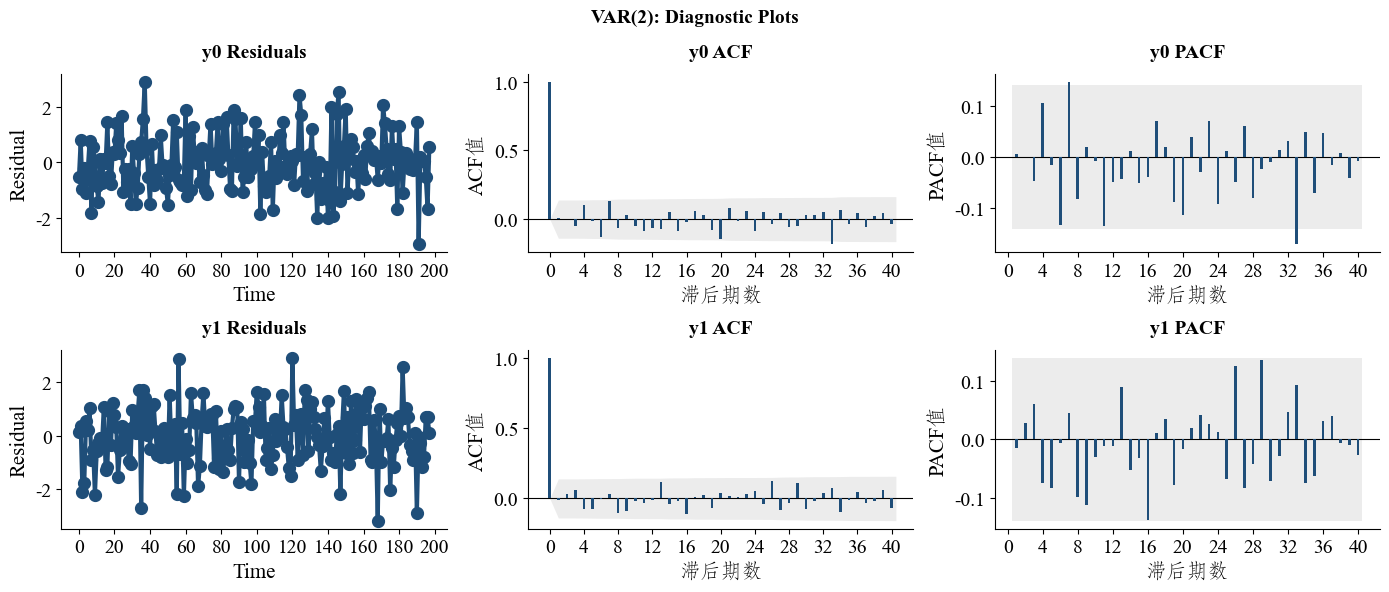

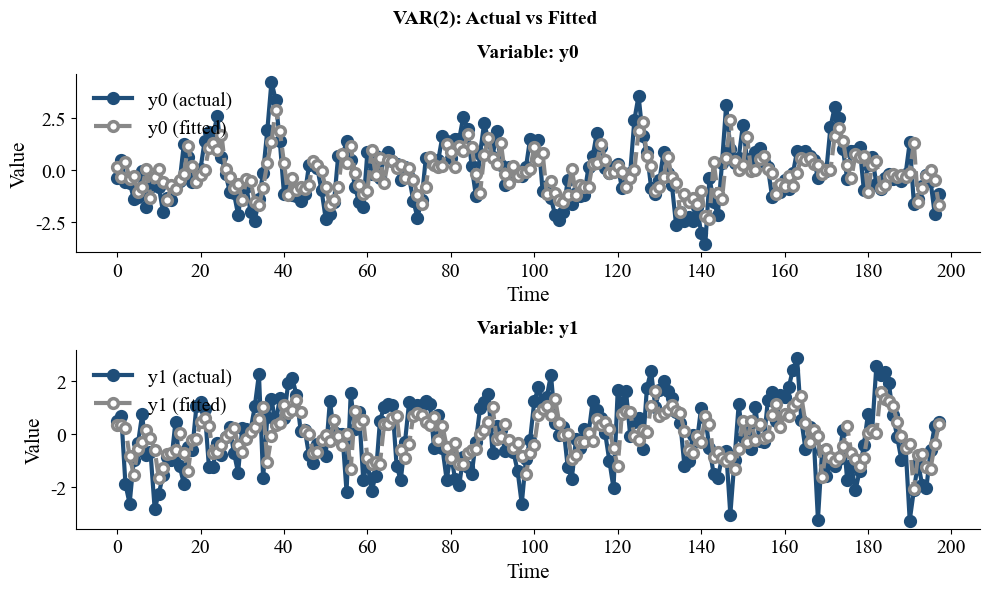


=== y0 残差诊断 ===
Residual Diagnostic Tests
Test                          Statistic    p-value  Conclusion
---------------------------------------------------------------------------
White Noise (Ljung-Box)          11.083     0.3511  White noise
Normality (Jarque-Bera)           1.777     0.4112  Normal
ARCH Effect (Ljung-Box)           7.322     0.6947  No ARCH effects
ARCH Effect (Engle LM)            6.992     0.7262  No ARCH effects

---------------------------------------------------------------------------

  Ljung-Box Q-Test
  Test Statistic: 11.083362
  P-value:        0.351060
  Lags:           10
  H0: No autocorrelation
  Effective obs.      : 198
  Conclusion (5%): Cannot reject H0 (no autocorrelation)

  Jarque-Bera Normality Test
  Test Statistic: 1.777154
  P-value:        0.411241
  Lags:           0
  H0: Normal distribution
  Skewness            : 0.2266
  Kurtosis            : 0.0997
  Effective obs.      : 198
  Conclusion (5%): Cannot reject H0 (normally distribute

In [37]:
# 多步预测 (含 95% 置信区间)
pr = result.predict(start=result.nobs, end=result.nobs + 7)
print(f"预测均值 shape: {pr.mean.shape}  (steps, k)")

# 诊断图: 每个变量的残差 + ACF + PACF
result.plot_diagnostics()
plt.show()

# 拟合图: 实际值 vs 拟合值
result.plot_fit()
plt.show()

# 残差检验: 每变量独立的四项诊断
resid_tests = result.test_residuals(lags=10)
for name, tests in resid_tests.items():
    print(f"\n=== {name} 残差诊断 ===")
    print(tests)

### 11.5 稳定性诊断 — `plot_roots()` 单位根图

`is_stable` 属性检查 VAR 平稳性；`plot_roots()` 在复平面单位圆上可视化
逆特征根。

**方法签名：** `plot_roots(title=None) → (fig, ax)`

| 参数 | 类型 | 说明 |
|------|------|------|
| `title` | `str`, optional | 自定义标题。`None` 时自动生成含稳定性结论的标题 |
| **返回** | `(Figure, Axes)` | matplotlib 图对象，可进一步修改后保存或显示 |

**相关属性：** `is_stable` — bool，所有逆特征根模长 < 1 时返回 `True`。

与 SARIMA 的 `plot_roots()` 的区别：VAR 只有一种根（特征多项式的逆根），
用**蓝色圆点**绘制，没有 AR/MA 的图形区分。</cell id="a6c631a1">


VAR is stable: True


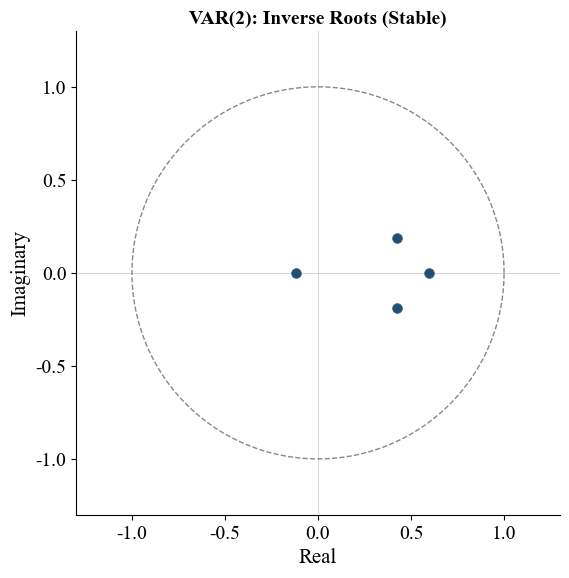

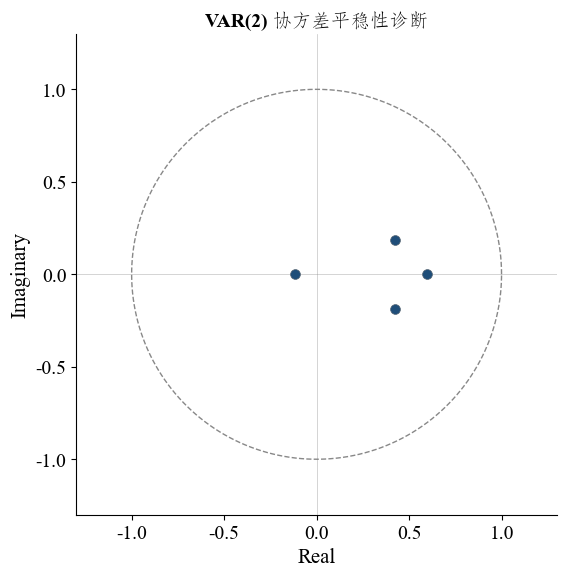

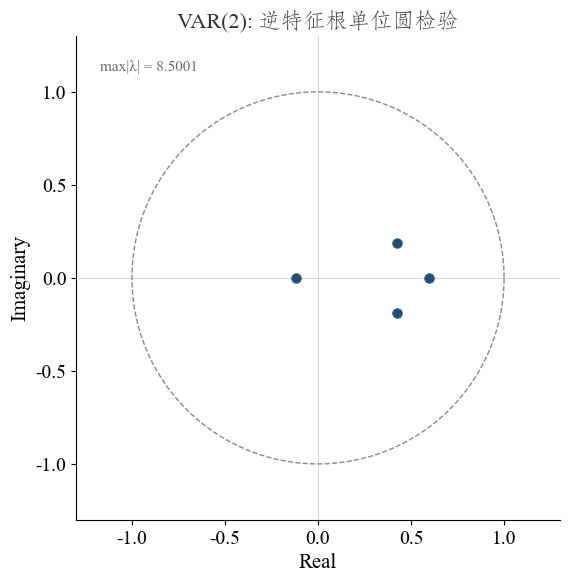

In [38]:
# === 基本用法：默认标题（含稳定性结论） ===
print(f"VAR is stable: {result.is_stable}")  # True = 所有逆根在单位圆内

fig, ax = result.plot_roots()  # 默认标题: "VAR(2): Inverse Roots (Stable)"
plt.show()

# === 自定义标题 ===
fig, ax = result.plot_roots(title="VAR(2) 协方差平稳性诊断")
plt.show()

# === 利用返回值自定义图形 ===
fig, ax = result.plot_roots()
ax.set_title("VAR(2): 逆特征根单位圆检验", fontsize=16, color="#333333")
# 标注模长最大的根
roots = result._var_result.roots
max_mod = np.max(np.abs(roots))
ax.annotate(f"max|λ| = {max_mod:.4f}", xy=(0.05, 0.95),
            xycoords="axes fraction", fontsize=11, color="#666666", va="top")
plt.show()
# 所有点落在单位圆内 (|z| < 1) = VAR 协方差平稳</cell id="f3c2cab1">


---
## 12. SVAR — 结构向量自回归

SVAR 在简化式 VAR 基础上施加识别约束，恢复结构性冲击。
支持短期约束 (A/B 矩阵) 和长期约束 (Blanchard-Quah)。

In [39]:
from Ts.TsModels import SVAR
import numpy as np

# === 短期约束 AB-model（Cholesky / 递归识别） ===
A = np.array([[1, 0], [np.nan, 1]])         # 下三角 A，1 个自由参数
B = np.array([[np.nan, 0], [0, np.nan]])     # 对角 B，2 个自由参数

svar_ab = SVAR(data_2d, lags=2, A=A, B=B)
result_ab = svar_ab.fit()
print(result_ab.summary())

# 估计的 A 和 B 矩阵
print(f"\nA matrix:\n{result_ab.A}")
print(f"\nB matrix:\n{result_ab.B}")

# 验证: A^(-1) B B^T A^(-T) = Sigma_u
sigma_implied = np.linalg.inv(result_ab.A) @ result_ab.B @ result_ab.B.T @ np.linalg.inv(result_ab.A).T
print(f"\nA^(-1) B B' A^(-T) equals Sigma_u: {np.allclose(sigma_implied, result_ab.sigma_u, atol=1e-10)}")

# 结构冲击正交性验证
eps = result_ab.structural_residuals
cov_eps = np.cov(eps, rowvar=False)
print(f"\nStructural shock covariance (should be I):\n{cov_eps}")

# === 结构性脉冲响应 (SIRF) ===
sirf = result_ab.irf(periods=10, orth=True, n_draws=50, seed=42)
print(f"\nSIRF shape: {sirf.values.shape}  (periods+1, k, k)")

# SIRF 与简化式 IRF 对比
rirf = result_ab.irf(periods=10, orth=False)
print(f"SIRF differs from reduced-form IRF: {not np.allclose(sirf.values, rirf.values)}")

# 即期冲击矩阵 = A^(-1) B
impact = np.linalg.inv(result_ab.A) @ result_ab.B
print(f"\nImpact matrix (Theta_0 = A^(-1) B):\n{impact}")
print(f"SIRF[0] equals impact: {np.allclose(sirf.values[0], impact, atol=1e-10)}")

# === 长期约束 (Blanchard-Quah) ===
C_lr = np.array([[np.nan, 0], [np.nan, np.nan]])  # C[0,1]=0: 需求冲击对产出的长期效应为零
svar_lr = SVAR(data_2d, lags=2, C_lr=C_lr)
result_lr = svar_lr.fit()
print("\n=== Long-run BQ ===")
print(f"B matrix:\n{result_lr.B}")

# 验证: Psi(1) @ B 是下三角 (长期零约束)
coefs = result_lr._var_result.coefs
A_sum = np.sum(coefs, axis=0)
psi1 = np.linalg.inv(np.eye(2) - A_sum)
lr_impact = psi1 @ result_lr.B
print(f"\nPsi(1) @ B (should be lower triangular):\n{lr_impact}")

# === 继承自 VARResult 的方法 ===
print(f"\nVAR stability: {result_ab.is_stable}")
gc = result_ab.granger_causality(caused=0, causing=1)
print(f"Granger causality p-value: {gc[0].p_value:.4f}")

SVAR (AB) Model Estimation Result
Variables  : y0, y1
Observations: 198
Log-Likelihood (SVAR): -205.8570
AIC         : 0.1292
BIC         : 0.2953

Structural parameters (A @ u = B @ eps):
----------------------------------------
  A = [[    1.0000      0.0000], [   -0.0746      1.0000]]
  B = [[    0.9903      0.0000], [    0.0000      1.0507]]

Equation: y0
----------------------------------------
  L1.y0                              0.7941  (0.0705)  p=0.0000
  L1.y1                             -0.0821  (0.0665)  p=0.2170
  L2.y0                             -0.1826  (0.0706)  p=0.0097
  L2.y1                              0.0444  (0.0665)  p=0.5045
  const                             -0.0544  (0.0709)  p=0.4431

Equation: y1
----------------------------------------
  L1.y0                             -0.1630  (0.0750)  p=0.0298
  L1.y1                              0.5401  (0.0707)  p=0.0000
  L2.y0                              0.1769  (0.0751)  p=0.0185
  L2.y1                       

---
## 13. VECM — 向量误差修正模型

VECM 是协整 VAR 系统的误差修正表示。当 Johansen 检验确认变量间存在
协整关系后，VECM 将 VAR 重新参数化为差分形式 + 误差修正项。

```python
VECM(data, lags=2, coint_rank=1, trend="c", cols=None)
```

| 参数 | 类型 | 默认值 | 说明 |
|------|------|--------|------|
| `data` | array-like (nobs, k) | — | 多变量时间序列 |
| `lags` | int | `2` | VAR 水平滞后阶数 (>= 2) |
| `coint_rank` | int | `1` | 协整秩 (1 <= r < k) |
| `trend` | str | `"c"` | `"n"` / `"c"` / `"ct"` |
| `cols` | list of str | `None` | 变量列名 |

VECM 通过 statsmodels VECM 采用 MLE 估计。
`summary()` 输出 Stata 风格格式：模型信息 + 方程汇总表 + 系数表 + beta 协整方程。

In [40]:
from Ts.TsModels import VECM
import numpy as np

# 生成 3 变量协整数据 (rank=2)
np.random.seed(42)
n = 300
x = np.cumsum(np.random.randn(n))
y = 2.0 * x + np.random.randn(n) * 0.5
z = 3.0 * x + np.random.randn(n) * 0.5
data = np.column_stack([z, y, x])

# VECM 估计: lags=2, coint_rank=2
model = VECM(data, lags=2, coint_rank=2, trend="c", cols=["Z", "Y", "X"])
result = model.fit()
print(result.summary())

# 关键参数矩阵
print(f"\nalpha shape: {result.alpha.shape}  (k x r)")
print(f"beta shape:  {result.beta.shape}  (k x r)")
print(f"gamma shape: {result.gamma.shape}  (k x k*(p-1))")

# 脉冲响应 (正交化)
irf = result.irf(periods=10, orth=True)

# 方差分解
fevd = result.fevd(periods=10)

# Granger 因果检验
gc = result.granger_causality(caused="Z", causing="Y", kind="chi2")
print(f"\nGranger causality (Y -> Z): p={gc.tests[0].p_value:.4f}")

# 稳定性
print(f"VECM is stable: {result.is_stable}")

# 残差诊断
result.test_residuals(lags=10)

Vector error-correction model
Sample: 2 - 299    Obs = 298    AIC = 1696.014    BIC = 1769.956
Log-Likelihood = -828.0069    Det(Sigma_ml) = 0.051999

Adjustment coefficients (α) — coef (z-stat), * p < 0.05
---------------------------------------------------------------------
     |                 _ce1                 _ce2                _cons
----+----------------------------------------------------------------
 D_Z |     -1.4496*( -2.92)     -0.0614 ( -0.13)      0.1551 (  0.85)
 D_Y |     -0.2578 ( -0.77)     -0.9699*( -2.94)      0.0220 (  0.18)
 D_X |     -0.1383 ( -0.84)     -0.0194 ( -0.12)      0.0094 (  0.16)
---------------------------------------------------------------------

Cointegrating vectors (β) — coef (z-stat), * p < 0.05
----------------------------------------------------
   beta |                  _ce1                  _ce2
-------+--------------------------------------------
      Z |         1.000 (norm)        0.0000 (  0.00)
      Y |      -0.0000 (  0.00)   

{'Z': ResidualTestResults(white_noise=LjungBoxTestResult(statistic=7.601314728163491, pvalue=0.66771583385717, lags=10, nobs=298, residuals=None, individual_lags=array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10]), individual_stats=array([0.01903765, 0.17947124, 0.4752846 , 2.35954524, 4.42946467,
        5.99772274, 6.01922411, 7.12077023, 7.13717901, 7.60131473]), individual_pvalues=array([0.89025861, 0.91417284, 0.92428674, 0.6699501 , 0.48937593,
        0.42344523, 0.53750645, 0.52366039, 0.62283953, 0.66771583]), apply_squared=False), normality=NormalityTestResult(statistic=2.565363147532657, pvalue=0.27729272168985614, lags=0, nobs=298, residuals=array([ 2.43167160e+00,  4.75167185e+00, -1.53160767e-01,  4.29437601e-01,
         4.07101264e+00,  2.34605911e+00, -2.30127334e+00,  1.67886490e+00,
        -1.74592591e+00, -1.37227225e+00,  6.13994229e-01, -6.45694029e+00,
        -4.39373361e+00, -2.71997926e+00, -2.38779155e+00,  9.17929929e-01,
        -2.45999069e+00, -4.33347183e+0

---
## 14. 真实样本外评估 (Out-of-Sample Evaluation)

`model.oos(split=...)` 会克隆模型，仅使用 `split` 之前的数据重新估计，
再预测完整持出区间。返回的 `OOSResult` 包含 `actual`、`mean`、置信区间、
目标索引及 MAE、MSE、RMSE、MAPE、sMAPE、Theil U1 等指标。

`predict()` 只负责已拟合模型的拟合值或未来预测，不再承担性能评估。

### 14.1 SARIMA 真实样本外评估

前 70% 数据用于估计，后 30% 是模型拟合时从未见过的持出区间。

=== SARIMA 样本外评估指标 ===
  mae       : 0.9594
  mse       : 1.5422
  rmse      : 1.2418
  mape      : 109.1458
  smape     : 143.3553
  theil_u1  : 0.7293
  n         : 60.0000

训练样本: [0, 140)
持出样本: [140, 200)


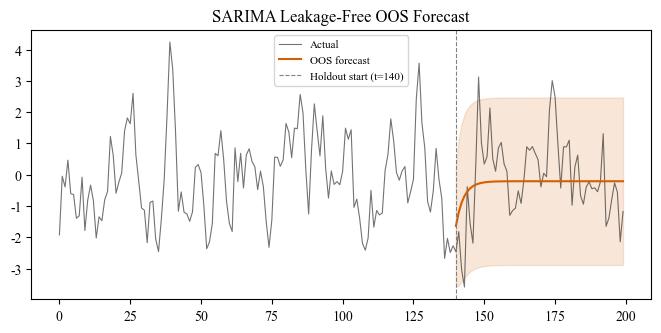

In [41]:
# SARIMA 真实样本外评估
sim = simulate_sarima(n=200, order=(1, 0, 0), ar=0.7, seed=42, burn=100)
model = SARIMA(sim.data, order=(1, 0, 0))
split = int(len(sim.data) * 0.7)
evaluation = model.oos(split=split)

print('=== SARIMA 样本外评估指标 ===')
for name, value in evaluation.metrics.items():
    print(f'  {name:<10s}: {value:.4f}')
print()
print(f'训练样本: [0, {split})')
print(f'持出样本: [{split}, {len(sim.data)})')

fig, ax = plt.subplots(figsize=(8, 3.5))
idx = evaluation.target_indices
ax.plot(np.arange(len(sim.data)), sim.data, color='black', linewidth=0.8,
        alpha=0.55, label='Actual')
ax.plot(idx, evaluation.mean, color='#D55E00', linewidth=1.5,
        label='OOS forecast')
if evaluation.lower is not None and evaluation.upper is not None:
    ax.fill_between(idx, evaluation.lower, evaluation.upper,
                    alpha=0.15, color='#D55E00')
ax.axvline(split, color='gray', linestyle='--', linewidth=0.8,
           label=f'Holdout start (t={split})')
ax.legend(fontsize=8)
ax.set_title('SARIMA Leakage-Free OOS Forecast')
plt.show()

### 14.2 GARCH 真实样本外评估

GARCH 的预测量是条件标准差。可观测评估目标定义为绝对去均值收益
`abs(y_t - mean(y_train))`，而不是不可观测的条件波动率，也不是平方残差。

=== GARCH 样本外评估指标 ===
评估目标: absolute_demeaned_return_proxy
  mae       : 0.5348
  mse       : 0.3938
  rmse      : 0.6276
  mape      : 465.6842
  smape     : 71.4094
  theil_u1  : 0.3146
  n         : 150.0000


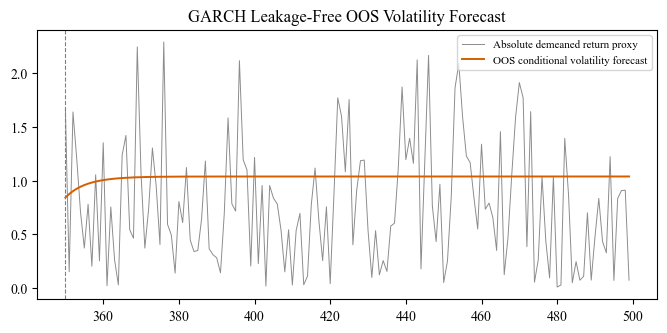

In [42]:
# GARCH 真实样本外评估
sim = simulate_garch(n=500, p=1, q=1, omega=0.1, alpha=0.2, beta=0.7,
                     seed=42, burn=300)
model = GARCH(sim.data, p=1, q=1)
split = int(len(sim.data) * 0.7)
evaluation = model.oos(split=split)

print('=== GARCH 样本外评估指标 ===')
print('评估目标:', evaluation.target)
for name, value in evaluation.metrics.items():
    print(f'  {name:<10s}: {value:.4f}')

fig, ax = plt.subplots(figsize=(8, 3.5))
idx = evaluation.target_indices
ax.plot(idx, evaluation.actual, color='black', linewidth=0.7,
        alpha=0.45, label='Absolute demeaned return proxy')
ax.plot(idx, evaluation.mean, color='#D55E00', linewidth=1.4,
        label='OOS conditional volatility forecast')
ax.axvline(split, color='gray', linestyle='--', linewidth=0.8)
ax.legend(fontsize=8)
ax.set_title('GARCH Leakage-Free OOS Volatility Forecast')
plt.show()

### 14.3 VAR 真实样本外评估

多变量结果同时给出合并指标和 `metrics_by_series`，避免只看总体误差掩盖
某个序列的预测失效。

=== VAR 样本外合并指标 ===
  mae       : 1.0785
  mse       : 1.8531
  rmse      : 1.3613
  mape      : 111.8889
  smape     : 167.2878
  theil_u1  : 0.8560
  n         : 120.0000

逐序列 RMSE:
  y0: 1.2840
  y1: 1.4344


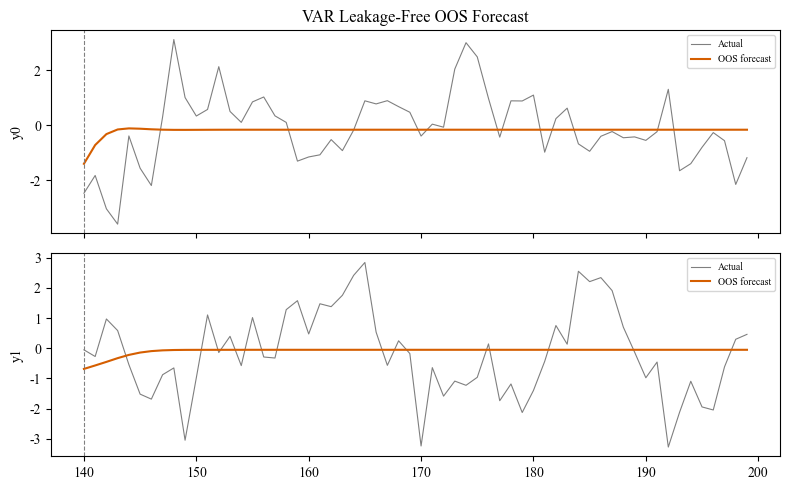

In [43]:
# VAR 真实样本外评估
r0 = simulate_sarima(n=200, order=(1, 0, 0), ar=[0.7], seed=42, burn=100)
r1 = simulate_sarima(n=200, order=(1, 0, 0), ar=[0.5], seed=99, burn=100)
data_2d = np.column_stack([r0.data, r1.data])

model = VAR(data_2d, lags=2, cols=['y0', 'y1'])
split = int(len(data_2d) * 0.7)
evaluation = model.oos(split=split)

print('=== VAR 样本外合并指标 ===')
for name, value in evaluation.metrics.items():
    print(f'  {name:<10s}: {value:.4f}')
print()
print('逐序列 RMSE:')
for col, metrics in zip(['y0', 'y1'], evaluation.metrics_by_series):
    print(f'  {col}: {metrics["rmse"]:.4f}')

fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
idx = evaluation.target_indices
for i, (ax, col) in enumerate(zip(axes, ['y0', 'y1'])):
    ax.plot(idx, evaluation.actual[:, i], color='black', linewidth=0.8,
            alpha=0.5, label='Actual')
    ax.plot(idx, evaluation.mean[:, i], color='#D55E00', linewidth=1.5,
            label='OOS forecast')
    ax.axvline(split, color='gray', linestyle='--', linewidth=0.8)
    ax.set_ylabel(col)
    ax.legend(fontsize=7)
axes[0].set_title('VAR Leakage-Free OOS Forecast')
plt.tight_layout()
plt.show()

### 14.4 样本外评估与未来外推分离

有真实值的持出区间用 `model.oos()` 评估；没有真实值的未来区间则先用全样本
拟合，再调用 `result.predict(start=nobs, end=...)`。两类结果不混入同一容器。

样本终点: t=199
未来预测: t=200 到 t=209
未来没有实际值，因此 PredictResult 不提供 actual 或 metrics。


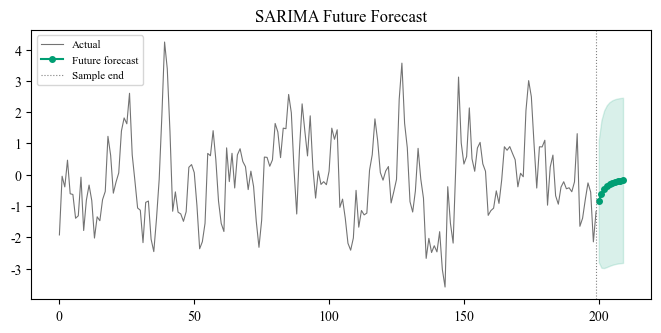

In [44]:
# SARIMA 未来外推：使用全样本拟合，不计算虚构的评估指标
sim = simulate_sarima(n=200, order=(1, 0, 0), ar=0.7, seed=42, burn=100)
result = SARIMA(sim.data, order=(1, 0, 0)).fit()

forecast_steps = 10
future = result.predict(
    start=result.nobs,
    end=result.nobs + forecast_steps - 1,
)
future_idx = np.arange(result.nobs, result.nobs + forecast_steps)

print(f'样本终点: t={result.nobs - 1}')
print(f'未来预测: t={future_idx[0]} 到 t={future_idx[-1]}')
print('未来没有实际值，因此 PredictResult 不提供 actual 或 metrics。')

fig, ax = plt.subplots(figsize=(8, 3.5))
observed_idx = np.arange(result.nobs)
ax.plot(observed_idx, sim.data, color='black', linewidth=0.8,
        alpha=0.55, label='Actual')
ax.plot(future_idx, future.mean, color='#009E73', linewidth=1.5,
        marker='o', markersize=4, label='Future forecast')
if future.lower is not None and future.upper is not None:
    ax.fill_between(future_idx, future.lower, future.upper,
                    alpha=0.15, color='#009E73')
ax.axvline(result.nobs - 1, color='gray', linestyle=':', linewidth=0.8,
           label='Sample end')
ax.legend(fontsize=8)
ax.set_title('SARIMA Future Forecast')
plt.show()

---
## 15. STL — 季节趋势分解

STL 使用 LOESS 将一维序列分解为趋势、季节项和残差。`robust=True` 会降低异常值对分解结果的影响。

STL Decomposition Result
Observations       : 120
Period             : 12
Robust             : True
Seasonal smoother  : 7
Trend smoother     : 23
Low-pass smoother  : 13
Residual std. dev. : 0.727404

重构最大误差: 1.776e-15
异常点权重: 0.000


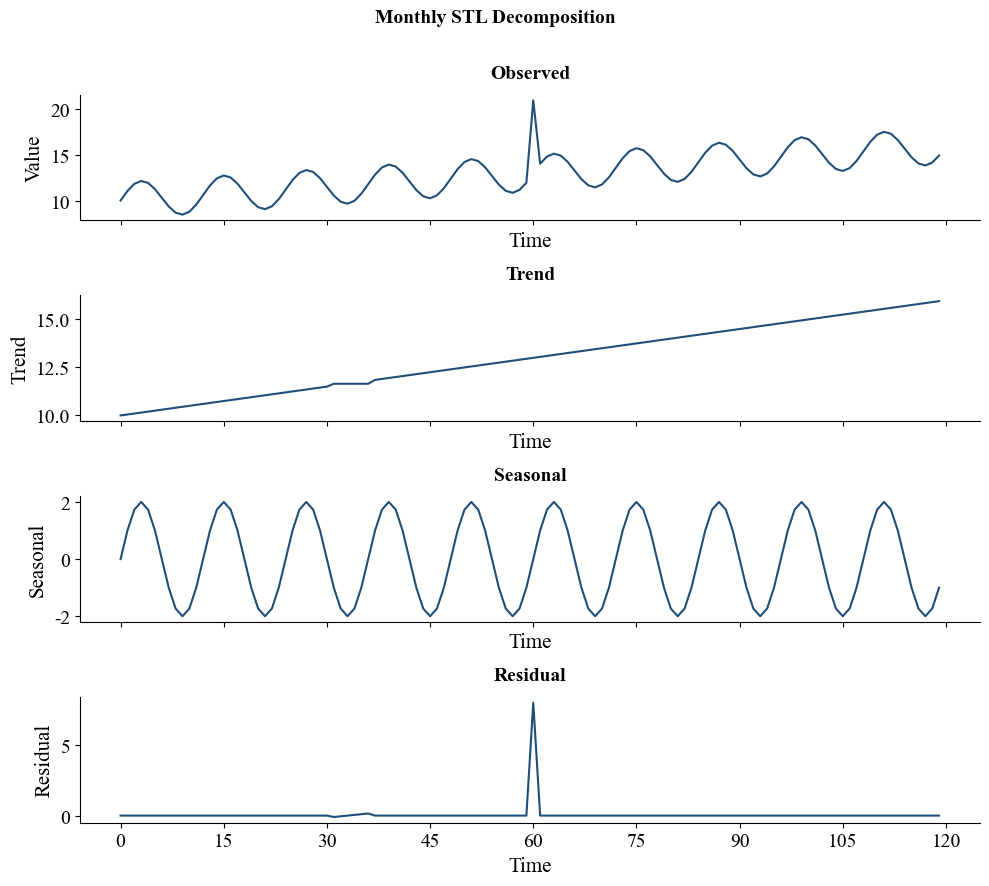

In [45]:
time = np.arange(120, dtype=float)
stl_data = 10 + 0.05 * time + 2 * np.sin(2 * np.pi * time / 12)
stl_data[60] += 8

stl_model = STL(stl_data, period=12, robust=True)
stl_result = stl_model.fit()
print(stl_result.summary())
print(f"\n重构最大误差: {np.max(np.abs(stl_result.observed - stl_result.fitted_values - stl_result.residuals)):.3e}")
print(f"异常点权重: {stl_result.weights[60]:.3f}")
stl_result.plot(title="Monthly STL Decomposition")
plt.show()

---
## 16. Backtesting 与 Backcasting

`backtest()` 在每个历史预测起点只使用当时可见的数据重新拟合，避免未来信息泄漏。`backcast()` 则反转时间、重新拟合并估计样本前数值；它是反向时间统计估计，不是因果历史重建。

In [46]:
from Ts.TsModels import SARIMA
from Ts.TsSims import simulate_sarima

evaluation_data = simulate_sarima(
    n=100,
    order=(1, 0, 0),
    ar=[0.7],
    seed=2026,
    burn=100,
).data
evaluation_model = SARIMA(evaluation_data, order=(1, 0, 0))

backtest_result = evaluation_model.backtest(
    initial_window=70,
    horizon=2,
    step=10,
)
backcast_result = evaluation_model.backcast(steps=4)

print("Backtest origins:", backtest_result.origins)
print("Backtest forecast shape:", backtest_result.mean.shape)
print("Backtest RMSE:", f"{backtest_result.metrics['rmse']:.4f}")
print("Backcast indices:", backcast_result.indices)
print("Backcast estimates:", np.round(backcast_result.mean, 4))

assert backtest_result.mean.shape == (3, 2)
assert backcast_result.indices.tolist() == [-4, -3, -2, -1]

Backtest origins: [70 80 90]
Backtest forecast shape: (3, 2)
Backtest RMSE: 0.8250
Backcast indices: [-4 -3 -2 -1]
Backcast estimates: [-0.4535 -0.7884 -1.2876 -2.0317]
